# EEE 457 Transmissão de Energia Elétrica
## Escola Politécnica
## Universidade Federal do Rio de Janeiro
### Antonio C. S. Lima
Agosto 2025

# Modelo de Linha Curta para Linhas de Transmissão Aéreas
Considere um circuito de 138kV com condutor ACSR, cabos para-raios de 3/8" EHS
as coordenadas dos condutores são aproximadamente

xc =[3.4, -  3.4,  3.4, -3.4, 3.4]

yc =[21.1, 19.2, 17.3, 24.9, 24.9]

In [1]:
# carrega as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 14,
    "font.sans-serif": "Helvetica",
})



# carrega os dados
# apenas para sequencia positiva
df = pd.read_csv('/Users/acsl/projects/transmissao/dados/138cst1.csv', usecols=["Cabo", "MCM", "Normal","r1", "x1", "b1"])
# visualizando
df.head(df.shape[0])

,Cabo,MCM,Normal,r1,x1,b1
0,1 x Linnet,336,435,0.1914,0.5014,3.3018
1,1 x Ibis,397,485,0.1622,0.4952,3.3456
2,1 x Hawk,477,540,0.1354,0.4883,3.3951
3,1 x Dove,556,595,0.1160,0.4821,3.4379
4,1 x Squab,605,625,0.1069,0.4790,3.4601
5,1 x Grosbeak,636,640,0.1017,0.4772,3.4748
6,1 x Gannet,666,660,0.0971,0.4753,3.4891
7,1 x Starling,716,690,0.0906,0.4727,3.5098
8,1 x Drake,795,735,0.0817,0.4690,3.5410
9,1 x Tern,795,730,0.0819,0.4734,3.5103


In [2]:
# com 50km de comprimento e tensão nominal do terminal receptor e fator de potência unitário
compr = 50

df["Zc"] = np.round(1e3*np.sqrt(df.x1/df.b1), 3)
df["Pn"] = np.round(138*138/(df.Zc),3)
ir = 1e3*np.round(df.Pn/(np.sqrt(3)*138),3)
df["Ir"] = np.abs(ir)
df["Vs"] = np.round( np.sqrt(3)/138e3* np.abs(138e3/np.sqrt(3)+df.Ir *(df.r1+1j* df.x1)*compr), 3)
df["loss"] = np.round(3*(df.Ir**2)*df.r1*compr,3)/1e6
df

,Cabo,MCM,Normal,r1,x1,b1,Zc,Pn,Ir,Vs,loss
0,1 x Linnet,336,435,0.1914,0.5014,3.3018,389.688,48.870,204.0,1.027,1.194795
1,1 x Ibis,397,485,0.1622,0.4952,3.3456,384.728,49.500,207.0,1.023,1.042516
2,1 x Hawk,477,540,0.1354,0.4883,3.3951,379.243,50.216,210.0,1.020,0.895671
3,1 x Dove,556,595,0.1160,0.4821,3.4379,374.474,50.855,213.0,1.018,0.789421
4,1 x Squab,605,625,0.1069,0.4790,3.4601,372.069,51.184,214.0,1.016,0.734339
5,1 x Grosbeak,636,640,0.1017,0.4772,3.4748,370.583,51.389,215.0,1.016,0.705162
6,1 x Gannet,666,660,0.0971,0.4753,3.4891,369.086,51.598,216.0,1.015,0.679545
7,1 x Starling,716,690,0.0906,0.4727,3.5098,366.988,51.893,217.0,1.014,0.639940
8,1 x Drake,795,735,0.0817,0.4690,3.5410,363.935,52.328,219.0,1.013,0.587762
9,1 x Tern,795,730,0.0819,0.4734,3.5103,367.233,51.858,217.0,1.013,0.578488


In [3]:
# com 50km de comprimento e tensão nominal do terminal receptor e fator de potência 0.9 indutivo 
theta = np.acos(.9)
iri = 1e3*np.round(df.Pn/(np.sqrt(3)*138 * np.cos(theta)),3) * np.exp(-1j * theta)
df["Ir"] = np.abs(iri)
df["Vs"] = np.round( np.sqrt(3)/138e3* np.abs(138e3/np.sqrt(3)+ ir *(df.r1+1j* df.x1)*compr), 3)
df["loss"] = np.round(3*(df.Ir**2)*df.r1*compr,3)/1e6
df

,Cabo,MCM,Normal,r1,x1,b1,Zc,Pn,Ir,Vs,loss
0,1 x Linnet,336,435,0.1914,0.5014,3.3018,389.688,48.870,227.0,1.027,1.479398
1,1 x Ibis,397,485,0.1622,0.4952,3.3456,384.728,49.500,230.0,1.023,1.287057
2,1 x Hawk,477,540,0.1354,0.4883,3.3951,379.243,50.216,233.0,1.020,1.102610
3,1 x Dove,556,595,0.1160,0.4821,3.4379,374.474,50.855,236.0,1.018,0.969110
4,1 x Squab,605,625,0.1069,0.4790,3.4601,372.069,51.184,238.0,1.016,0.908287
5,1 x Grosbeak,636,640,0.1017,0.4772,3.4748,370.583,51.389,239.0,1.016,0.871381
6,1 x Gannet,666,660,0.0971,0.4753,3.4891,369.086,51.598,240.0,1.015,0.838944
7,1 x Starling,716,690,0.0906,0.4727,3.5098,366.988,51.893,241.0,1.014,0.789321
8,1 x Drake,795,735,0.0817,0.4690,3.5410,363.935,52.328,243.0,1.013,0.723645
9,1 x Tern,795,730,0.0819,0.4734,3.5103,367.233,51.858,241.0,1.013,0.713525


In [4]:
# com 50km de comprimento e tensão nominal do terminal receptor e fator de potência  capacitivo 
irc = 1e3*np.round(df.Pn/(np.sqrt(3) * 138 * np.cos(theta)),3) * np.exp(1j * theta)
df["Ir"] = np.abs(irc)
df["Vs"] = np.round( np.sqrt(3)/138e3* np.abs(138e3/np.sqrt(3)+ ir *(df.r1+1j* df.x1)*compr), 3)
df["loss"] = np.round(3*(df.Ir**2)*df.r1*compr,3)/1e6
df

,Cabo,MCM,Normal,r1,x1,b1,Zc,Pn,Ir,Vs,loss
0,1 x Linnet,336,435,0.1914,0.5014,3.3018,389.688,48.870,227.0,1.027,1.479398
1,1 x Ibis,397,485,0.1622,0.4952,3.3456,384.728,49.500,230.0,1.023,1.287057
2,1 x Hawk,477,540,0.1354,0.4883,3.3951,379.243,50.216,233.0,1.020,1.102610
3,1 x Dove,556,595,0.1160,0.4821,3.4379,374.474,50.855,236.0,1.018,0.969110
4,1 x Squab,605,625,0.1069,0.4790,3.4601,372.069,51.184,238.0,1.016,0.908287
5,1 x Grosbeak,636,640,0.1017,0.4772,3.4748,370.583,51.389,239.0,1.016,0.871381
6,1 x Gannet,666,660,0.0971,0.4753,3.4891,369.086,51.598,240.0,1.015,0.838944
7,1 x Starling,716,690,0.0906,0.4727,3.5098,366.988,51.893,241.0,1.014,0.789321
8,1 x Drake,795,735,0.0817,0.4690,3.5410,363.935,52.328,243.0,1.013,0.723645
9,1 x Tern,795,730,0.0819,0.4734,3.5103,367.233,51.858,241.0,1.013,0.713525


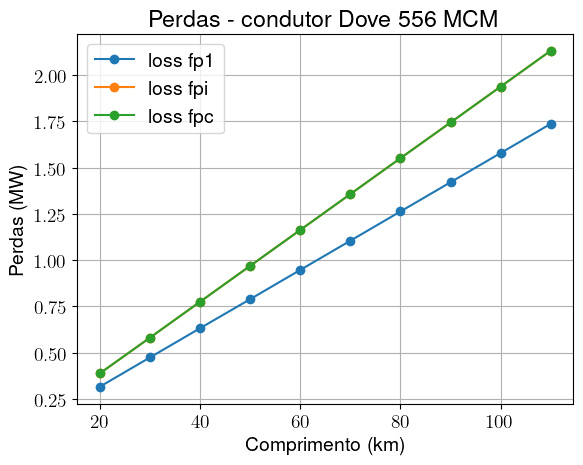

In [5]:
# verificaçao do comportamento das perdas em funçao do comprimento
# considerando o condutor Dove (556 MCM)
compr =  np.linspace(20.,110.,10)
df2 = pd.DataFrame(compr, columns=["compr"])
r  = df.r1[3]
ir0 = np.abs(ir[3])
ir1 = np.abs(iri[3])
ir2 = np.abs(irc[3])
df2["loss fp1"] = np.round(3*( ir0 **2  * r * df2.compr)/1e6,3)
df2["loss fpi"] = np.round(3*( ir1 **2  * r * df2.compr)/1e6,3)
df2["loss fpc"] = np.round(3*( ir2 **2   * r * df2.compr)/1e6,3)

df2.plot(x="compr", y=["loss fp1","loss fpi","loss fpc"], marker='o')
plt.title("Perdas - condutor Dove 556 MCM")
plt.ylabel("Perdas (MW)")
plt.xlabel("Comprimento (km)")
plt.grid()
plt.show()

In [6]:
# Compare o resultado o resultado obtido acima com aquele usando o modelo de linha lonha
# considerando condutor  556 MCM (Dove), 50 km de comprimento, tensão nominal no terminal receptor, 
# fator de potência unitário  

z = df.r1[3] + 1j * df.x1[3]
y = 1j * df.b1[3] * 1e-6
zc = np.sqrt(z/y )
gammal = np.sqrt(z * y) * 50
v = 138e3/np.sqrt(3)
a = np.cosh(gammal)
b = zc * np.sinh(gammal)
c = (1/zc) * np.sinh(gammal)
d = a
ir = df.Pn[3]*1e6/(np.sqrt(3)*138e3)
vs  = a * v +b * ir
is_ = c * v + d * ir
ps = 3 * np.real(vs * np.conj(is_))
ploss = ps - df.Pn[3]*1e6 
ploss = np.round(ploss/1e6,3)
out1 = np.round(np.abs(vs)*np.sqrt(3)/138e3,3)
out2 = np.round(np.abs(ir),3)
out3 = np.round(np.abs(is_),3)
out4 = np.round(ploss,3)

print(out1, out2, out3, out4)

1.015 212.762 212.767 0.788


## Compando os gráficos de perdas 

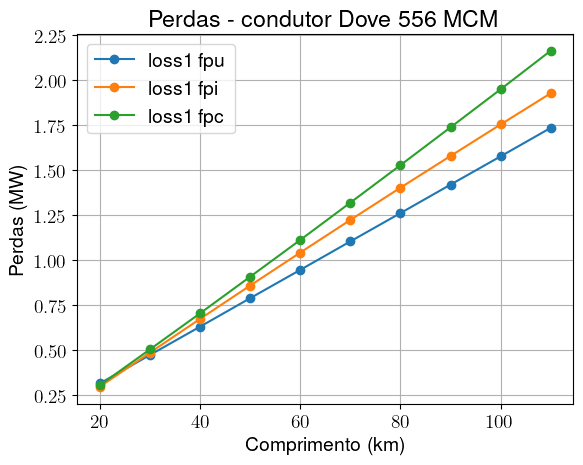

In [7]:
# para as mesmas condiçoes, f.p unitário, 0.9 atrasado e 0.9 adiantado 
# ir0 = np.abs(ir[3])
# ir1 = np.abs(iri[3])
# ir2 = np.abs(irc[3])
# mesmos parametros do circuito
# z = df.r1[3] + 1j * df.x1[3]
# y = 1j * df.b1[3] * 1e-6
# zc = np.sqrt(z/y )
gammal1 = np.sqrt(z * y) * compr
v = 138e3/np.sqrt(3)
a = np.cosh(gammal1)
b = zc * np.sinh(gammal1)
c = (1/zc) * np.sinh(gammal1)
d = a
# para fator de potência unitario
# ir = df.Pn[3]*1e6/(np.sqrt(3)*138e3)
vs  = a * v +b * ir
is_ = c * v + d * ir
ps = 3 * np.real(vs * np.conj(is_))
ploss = ps - df.Pn[3] * 1e6 
ploss = np.round(ploss/1e6,3)
df2["loss1 fpu"] = ploss

# para fator de potência 0.9 atrasado
vs  = a * v +b * iri[3]
is_ = c * v + d * iri[3]
ps = 3 * np.real(vs * np.conj(is_))
ploss1 = ps - df.Pn[3]*1e6 
ploss1 = np.round(ploss1/1e6,3)
df2["loss1 fpi"] = ploss1

# para fator de potência 0.9 adiantado
vs  = a * v +b * irc[3]
is_ = c * v + d * irc[3]
ps = 3 * np.real(vs * np.conj(is_))
ploss2 = ps - df.Pn[3]*1e6 
ploss2 = np.round(ploss2/1e6,3)
df2["loss1 fpc"] = ploss2 

df2.plot(x="compr", y=["loss1 fpu","loss1 fpi","loss1 fpc"], marker='o')
plt.title("Perdas - condutor Dove 556 MCM")
plt.ylabel("Perdas (MW)")
plt.xlabel("Comprimento (km)")
plt.grid()
plt.show()

### Como explicar essas diferenças?

será q empregando o modelo de linha média também teremos essas diferenças?